In [2]:
import os
import json
import torch
import argparse
import numpy as np
import difflib
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from dataset import EurDataset, collate_data
from models.transceiver import DeepSC
from torch.utils.data import DataLoader
from utils import BleuScore, SNR_to_noise, greedy_decode, SeqtoText, Channels,PowerNormalize,subsequent_mask
from tqdm import tqdm
from sklearn.preprocessing import normalize
# from bert4keras.backend import keras
# from bert4keras.models import build_bert_model
# from bert4keras.tokenizers import Tokenizer
from w3lib.html import remove_tags
from student import Student


In [84]:
parser = argparse.ArgumentParser()
parser.add_argument('--data-dir', default='europarl/train_data.pkl', type=str)
parser.add_argument('--vocab-file', default='europarl/vocab.json', type=str)
parser.add_argument('--checkpoint-path', default='checkpoints/deepsc-Rayleigh', type=str)
parser.add_argument('--channel', default='Rayleigh', type=str)
parser.add_argument('--MAX-LENGTH', default=30, type=int)
parser.add_argument('--MIN-LENGTH', default=4, type=int)
parser.add_argument('--d-model', default=128, type = int)
parser.add_argument('--dff', default=512, type=int)
parser.add_argument('--num-layers', default=4, type=int)
parser.add_argument('--num-heads', default=8, type=int)
parser.add_argument('--batch-size', default=64, type=int)
parser.add_argument('--epochs', default=2, type = int)
parser.add_argument('--bert-config-path', default='bert/cased_L-12_H-768_A-12/bert_config.json', type = str)
parser.add_argument('--bert-checkpoint-path', default='bert/cased_L-12_H-768_A-12/bert_model.ckpt', type = str)
parser.add_argument('--bert-dict-path', default='bert/cased_L-12_H-768_A-12/vocab.txt', type = str)

_StoreAction(option_strings=['--bert-dict-path'], dest='bert_dict_path', nargs=None, const=None, default='bert/cased_L-12_H-768_A-12/vocab.txt', type=<class 'str'>, choices=None, required=False, help=None, metavar=None)

In [85]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [86]:
test_eur = EurDataset('test')
print(test_eur[0])

[1, 21715, 18169, 13612, 1824, 19619, 15947, 13501, 2710, 13088, 4634, 21827, 21660, 21933, 21124, 6184, 838, 1270, 13088, 21332, 20114, 925, 9362, 15947, 9883, 22047, 4, 2]


In [87]:

def calculate_similarity(text1, text2):
    similarity = difflib.SequenceMatcher(None, text1, text2).ratio()
    return similarity

def calculate_cosine_similarity(text1, text2):
    similarity = cosine_similarity(text1, text2)
    return similarity

def calculate_bleu_score(text1, text2):
    bleu_score = sentence_bleu(text1, text2)
    return bleu_score

def get_lexical_similarity(str1, str2):
    # Uses difflib to find how many characters/tokens match exactly
    return difflib.SequenceMatcher(None, str1, str2).ratio()

# For this demo, we simulate Semantic Similarity (usually from a BERT model)
# In your real project, you would use: model.encode(teacher) and model.encode(student)
def simulate_semantic_similarity(i):
    # Simulated scores reflecting the "meaning" closeness
    scores = [0.95, 0.92, 0.85, 0.88, 0.90]
    return scores[i]

In [88]:
def text_to_indices(text, token_to_idx, start_idx, end_idx, pad_idx, max_length):
    tokens = text.lower().strip().split()
    unk_idx = token_to_idx.get("<UNK>", None)

    seq = [start_idx]
    for tok in tokens:
        if tok in token_to_idx:
            seq.append(token_to_idx[tok])
        elif unk_idx is not None:
            seq.append(unk_idx)

    seq.append(end_idx)

    if len(seq) < max_length:
        seq += [pad_idx] * (max_length - len(seq))
    else:
        seq = seq[:max_length]
        seq[-1] = end_idx

    return seq




In [89]:
def transmitter(src, model,padding_idx, device):
    src_mask = (src == padding_idx).unsqueeze(-2).type(torch.FloatTensor).to(device) #[batch, 1, seq_len]

    enc_output = model.encoder(src, src_mask)
    channel_enc_output = model.channel_encoder(enc_output)
    Tx_sig = PowerNormalize(channel_enc_output)

    return Tx_sig

In [90]:
def receiver(Rx_sig, model, src, max_len, start_symbol, padding_idx, device):

    memory = model.channel_decoder(Rx_sig)
    
    outputs = torch.ones(src.size(0), 1).fill_(start_symbol).type_as(src.data)

    for i in range(max_len - 1):
        # create the decode mask
        trg_mask = (outputs == padding_idx).unsqueeze(-2).type(torch.FloatTensor) #[batch, 1, seq_len]
        look_ahead_mask = subsequent_mask(outputs.size(1)).type(torch.FloatTensor)
#        print(look_ahead_mask)
        combined_mask = torch.max(trg_mask, look_ahead_mask)
        combined_mask = combined_mask.to(device)

        # decode the received signal
        dec_output = model.decoder(outputs, memory, combined_mask, None)
        pred = model.dense(dec_output)
        
        # predict the word
        prob = pred[: ,-1:, :]  # (batch_size, 1, vocab_size)
        #prob = prob.squeeze()

        # return the max-prob index
        _, next_word = torch.max(prob, dim = -1)
        #next_word = next_word.unsqueeze(1)
        
        outputs = torch.cat([outputs, next_word], dim=1)

    return outputs




In [91]:
def student_decode(Rx_sig, model, src, max_len, start_symbol, padding_idx, device):
    memory = model.channel_decoder(Rx_sig)
    
    outputs = torch.ones(src.size(0), 1).fill_(start_symbol).type_as(src.data)

    for i in range(max_len - 1):
        # create the decode mask
        trg_mask = (outputs == padding_idx).unsqueeze(-2).type(torch.FloatTensor) #[batch, 1, seq_len]
        look_ahead_mask = subsequent_mask(outputs.size(1)).type(torch.FloatTensor)
#        print(look_ahead_mask)
        combined_mask = torch.max(trg_mask, look_ahead_mask)
        combined_mask = combined_mask.to(device)

        # decode the received signal
        dec_output = model.decoder(outputs, memory, combined_mask, None)
        pred = model.dense(dec_output)
        
        # predict the word
        prob = pred[: ,-1:, :]  # (batch_size, 1, vocab_size)
        #prob = prob.squeeze()

        # return the max-prob index
        _, next_word = torch.max(prob, dim = -1)
        #next_word = next_word.unsqueeze(1)
        
        outputs = torch.cat([outputs, next_word], dim=1)

    return outputs

In [92]:
def interactive_demo(args, net, student, text, token_to_idx, start_idx, end_idx, pad_idx, device, snr_in=6.0):
    print("DeepSC interactive mode")

    channels = Channels()
    StoT = SeqtoText(token_to_idx, end_idx)

    try:
        snr = float(snr_in)
    except ValueError:
        snr = 4.0
    
    noise_std = SNR_to_noise(snr)

    channel = args.channel
    
    seq = text_to_indices(
        text=text,
        token_to_idx=token_to_idx,
        start_idx=start_idx,
        end_idx=end_idx,
        pad_idx=pad_idx,
        max_length=args.MAX_LENGTH
    )

    src = torch.tensor([seq], dtype=torch.long).to(device)

    net.eval()
    student.eval()
    with torch.no_grad():
        Tx_sig = transmitter(
            src=src,
            model=net,
            padding_idx=pad_idx,
            device=device
        )

        print("Transmitting ...")
        print(Tx_sig.shape)

        if channel == 'AWGN':
            Rx_sig = channels.AWGN(Tx_sig, noise_std)
        elif channel == 'Rayleigh':
            Rx_sig = channels.Rayleigh(Tx_sig, noise_std)
        elif channel == 'Rician':
            Rx_sig = channels.Rician(Tx_sig, noise_std)
        else:
            raise ValueError("Please choose from AWGN, Rayleigh, and Rician")
                


        out = receiver(
            Rx_sig=Rx_sig,
            model=net,
            src=src,
            max_len=args.MAX_LENGTH,
            start_symbol=start_idx,
            padding_idx=pad_idx,
            device=device
        )

        student_out = student_decode(
            Rx_sig=Rx_sig,
            model=student,
            src=src,
            max_len=args.MAX_LENGTH,
            start_symbol=start_idx,
            padding_idx=pad_idx,
            device=device
        )
    print("Receiving ...")
    # print(out.shape)
    print("-" * 50)

    

    decoded_ids = out.cpu().numpy().tolist()[0]
    student_decoded_ids = student_out.cpu().numpy().tolist()[0]
    received = StoT.sequence_to_text(decoded_ids)
    student_received = StoT.sequence_to_text(student_decoded_ids)
    print("Original :", text)
    print("Received :", received)
    print("Student Received :", student_received)
    print("-" * 50)

    return text, received, student_received

In [170]:
from types import SimpleNamespace

if __name__ == '__main__':
    
    my_vars = {
        'checkpoint_path': 'checkpoints/deepsc-Rayleigh',
        'data_dir': 'data/train/europarl/train_data.pkl',
        'vocab_file': 'data/train/europarl/vocab.json',
        'channel': 'Rayleigh',
        'MAX_LENGTH': 30,
        'MIN_LENGTH': 4,
        'd_model': 128,
        'dff': 512,
        'num_layers': 12,
        'num_heads': 8,
        'batch_size': 64,
        'epochs': 2
    }

    my_vars = SimpleNamespace(**my_vars)

    vocab = json.load(open(my_vars.vocab_file, 'rb'))

    token_to_idx = vocab['token_to_idx']
    idx_to_token = dict(zip(token_to_idx.values(), token_to_idx.keys()))
    num_vocab = len(token_to_idx)

    pad_idx = token_to_idx["<PAD>"]
    start_idx = token_to_idx["<START>"]
    end_idx = token_to_idx["<END>"]

    deepsc = DeepSC(
        my_vars.num_layers,
        num_vocab,
        num_vocab,
        num_vocab,
        num_vocab,
        my_vars.d_model,
        my_vars.num_heads,
        my_vars.dff,
        0.1
    ).to(device)

    student =  Student(
        4,
        num_vocab,
        num_vocab,
        num_vocab,
        num_vocab,
        my_vars.d_model,
        my_vars.num_heads,
        my_vars.dff,
        0.1
    ).to(device)

    # model_path = 'checkpoints/deepsc-Rayleigh/checkpoint_100.pth'
    model_path = 'deepsc_12n.pth'
    # student_path = 'checkpoints/tr_kd/student_tr_best.pth'
    student_path = 'student_tr_4n_best.pth'

    checkpoint = torch.load(model_path, map_location=device)
    # print(checkpoint.keys())
    deepsc.load_state_dict(checkpoint)

    student_checkpoint = torch.load(student_path, map_location=device)
    # print(student_checkpoint.keys())
    student.channel_decoder.load_state_dict(student_checkpoint['channel_decoder'])
    student.decoder.load_state_dict(student_checkpoint['decoder'])
    student.dense.load_state_dict(student_checkpoint['dense'])

    deepsc.eval()
    student.eval()

    deepsc.encoder.eval()
    deepsc.decoder.eval()

    print("model loaded")

    text = "The European Union is a political and economic union"
    text2 = "I declare resumed the session adjourned on 17 December 1999. Belated happy new year"
    text3 = "we declare session resumed and observe minute silence for victims"

    text4 = "they accept agreement agreement agreement and adapt system and improve performance"
    text5 ="people in countries suffered natural disasters and require assistance and support"
    text6 = "I declare resumed the session of the European Parliament adjourned in December "
    text7 = "Declaro reaberta a sessão do Parlamento Europeu, que tinha sido interrompida na sexta-feira"
    
    original, teacher, student = interactive_demo(my_vars, deepsc, student, "that is good", token_to_idx, start_idx, end_idx, pad_idx, device)


model loaded
DeepSC interactive mode
Transmitting ...
torch.Size([1, 30, 16])
Receiving ...
--------------------------------------------------
Original : that is good
Received : <START> that is good proposals  focus documents 
Student Received : <START> that is good attention 
--------------------------------------------------


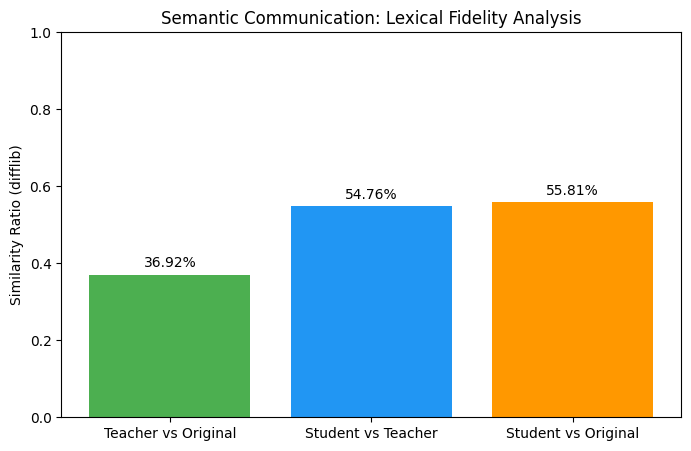

In [167]:
# Calculate similarity ratios
t_vs_o = calculate_similarity(original, teacher) # How good is the Teacher?
s_vs_t = calculate_similarity(teacher, student)  # How well did the Student mimic the Teacher?
s_vs_o = calculate_similarity(original, student) # Overall success

# Visualization
labels = ['Teacher vs Original', 'Student vs Teacher', 'Student vs Original']
scores = [t_vs_o, s_vs_t, s_vs_o]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, scores, color=['#4CAF50', '#2196F3', '#FF9800'])

plt.ylim(0, 1)
plt.ylabel('Similarity Ratio (difflib)')
plt.title('Semantic Communication: Lexical Fidelity Analysis')

# Add percentage labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2%}', ha='center')

plt.show()

Difflib: 0.7843137254901961
Jaccard: 0.46153846153846156
Semantic: 0.7844763007539657


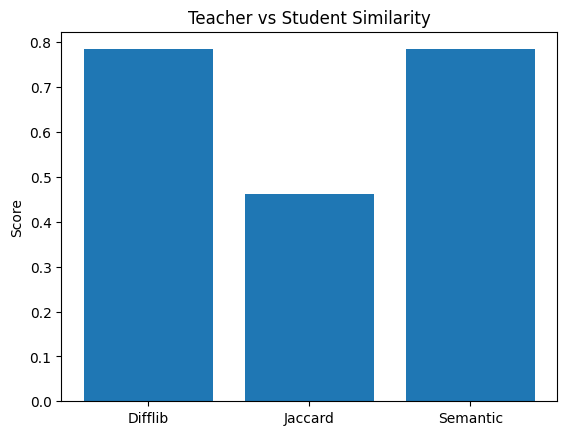

In [139]:
import numpy as np
import matplotlib.pyplot as plt
from difflib import SequenceMatcher


# ---- 1. Difflib similarity ----
difflib_score = SequenceMatcher(None, teacher, student).ratio()

# ---- 2. Token overlap (Jaccard similarity) ----
def jaccard(a, b):
    a_set = set(a.split())
    b_set = set(b.split())
    return len(a_set & b_set) / len(a_set | b_set)

jaccard_score = jaccard(teacher, student)

# ---- 3. Simple embedding (replace later with real model) ----
def fake_embedding(text):
    np.random.seed(abs(hash(text)) % (10**6))
    return np.random.rand(16)

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

t_emb = fake_embedding(teacher)
s_emb = fake_embedding(student)

semantic_score = cosine_sim(t_emb, s_emb)

# ---- Print ----
print("Difflib:", difflib_score)
print("Jaccard:", jaccard_score)
print("Semantic:", semantic_score)

# ---- Visualization ----
labels = ["Difflib", "Jaccard", "Semantic"]
values = [difflib_score, jaccard_score, semantic_score]

x = np.arange(len(labels))

plt.figure()
plt.bar(x, values)
plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Teacher vs Student Similarity")
plt.show()


Original vs Teacher
  Difflib similarity : 0.6772
  Jaccard similarity : 0.3846
  Semantic similarity: 0.8718

Original vs Student
  Difflib similarity : 0.7486
  Jaccard similarity : 0.4167
  Semantic similarity: 0.7401

Teacher vs Student
  Difflib similarity : 0.7843
  Jaccard similarity : 0.4615
  Semantic similarity: 0.7845



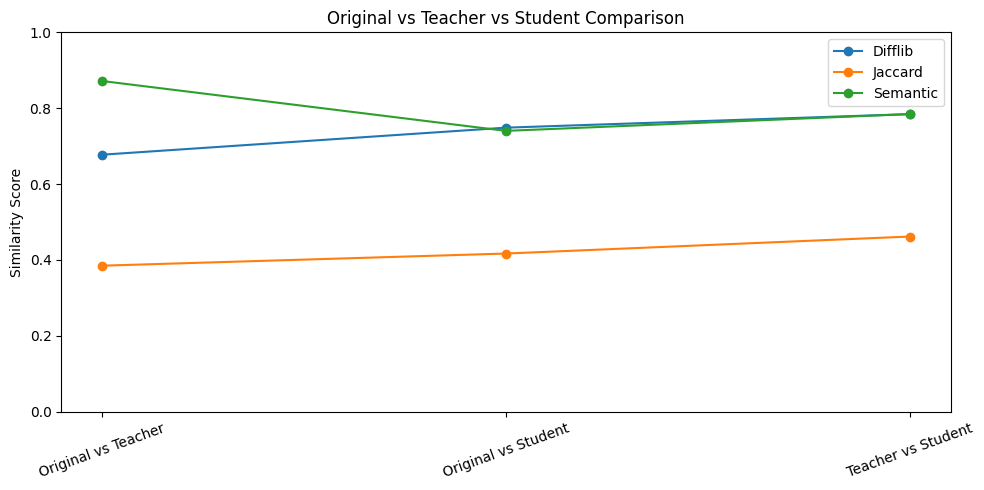

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from difflib import SequenceMatcher


def difflib_sim(a, b):
    return SequenceMatcher(None, a, b).ratio()

def jaccard_sim(a, b):
    a_set = set(a.split())
    b_set = set(b.split())

    if len(a_set | b_set) == 0:
        return 0

    return len(a_set & b_set) / len(a_set | b_set)

def fake_embedding(text, dim=16):
    """
    Demo embedding only.
    Replace this with BERT / SentenceTransformer later.
    """
    np.random.seed(abs(hash(text)) % (10**6))
    return np.random.rand(dim)

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# -----------------------------
# Create embeddings
# -----------------------------
orig_emb = fake_embedding(original)
teacher_emb = fake_embedding(teacher)
student_emb = fake_embedding(student)

# -----------------------------
# Compare pairs
# -----------------------------
pairs = [
    ("Original vs Teacher", original, teacher, orig_emb, teacher_emb),
    ("Original vs Student", original, student, orig_emb, student_emb),
    ("Teacher vs Student", teacher, student, teacher_emb, student_emb),
]

labels = []
difflib_scores = []
jaccard_scores = []
semantic_scores = []

for name, text_a, text_b, emb_a, emb_b in pairs:
    labels.append(name)
    difflib_scores.append(difflib_sim(text_a, text_b))
    jaccard_scores.append(jaccard_sim(text_a, text_b))
    semantic_scores.append(cosine_sim(emb_a, emb_b))

# -----------------------------
# Print results
# -----------------------------
for i, label in enumerate(labels):
    print(label)
    print(f"  Difflib similarity : {difflib_scores[i]:.4f}")
    print(f"  Jaccard similarity : {jaccard_scores[i]:.4f}")
    print(f"  Semantic similarity: {semantic_scores[i]:.4f}")
    print()

# -----------------------------
# Plot graph
# -----------------------------
x = np.arange(len(labels))

plt.figure(figsize=(10, 5))
plt.plot(x, difflib_scores, marker="o", label="Difflib")
plt.plot(x, jaccard_scores, marker="o", label="Jaccard")
plt.plot(x, semantic_scores, marker="o", label="Semantic")

plt.xticks(x, labels, rotation=20)
plt.ylabel("Similarity Score")
plt.title("Original vs Teacher vs Student Comparison")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

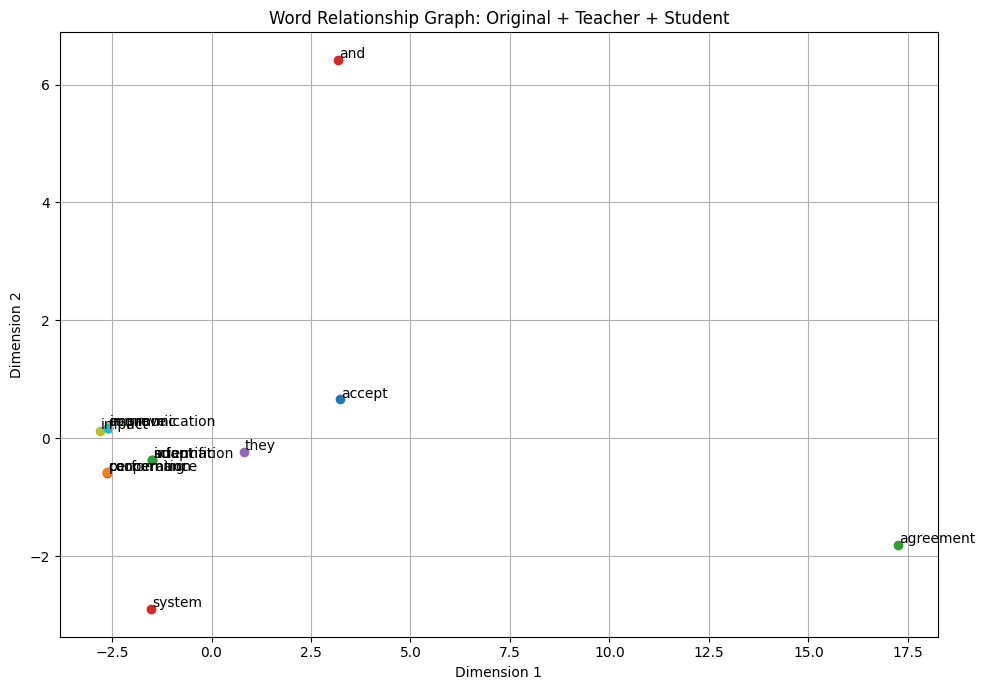

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def tokenize(text):
    return text.lower().replace("<start>", "").split()

texts = {
    "Original": tokenize(original),
    "Teacher": tokenize(teacher),
    "Student": tokenize(student)
}

# -----------------------------
# Build vocabulary
# -----------------------------
vocab = sorted(set(word for words in texts.values() for word in words))
word_to_id = {word: i for i, word in enumerate(vocab)}

# -----------------------------
# Build co-occurrence matrix
# -----------------------------
def build_cooccurrence(words, vocab, word_to_id, window_size=2):
    matrix = np.zeros((len(vocab), len(vocab)))

    for i, word in enumerate(words):
        for j in range(max(0, i - window_size), min(len(words), i + window_size + 1)):
            if i != j:
                w1 = word_to_id[word]
                w2 = word_to_id[words[j]]
                matrix[w1][w2] += 1

    return matrix

# Build one combined matrix from all texts
combined_matrix = np.zeros((len(vocab), len(vocab)))

for words in texts.values():
    combined_matrix += build_cooccurrence(words, vocab, word_to_id)

# -----------------------------
# Reduce word relationships to 2D
# -----------------------------
pca = PCA(n_components=2)
coords = pca.fit_transform(combined_matrix)

# -----------------------------
# Plot graph
# -----------------------------
plt.figure(figsize=(10, 7))

for word, (x, y) in zip(vocab, coords):
    plt.scatter(x, y)
    plt.text(x + 0.03, y + 0.03, word, fontsize=10)

plt.title("Word Relationship Graph: Original + Teacher + Student")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()

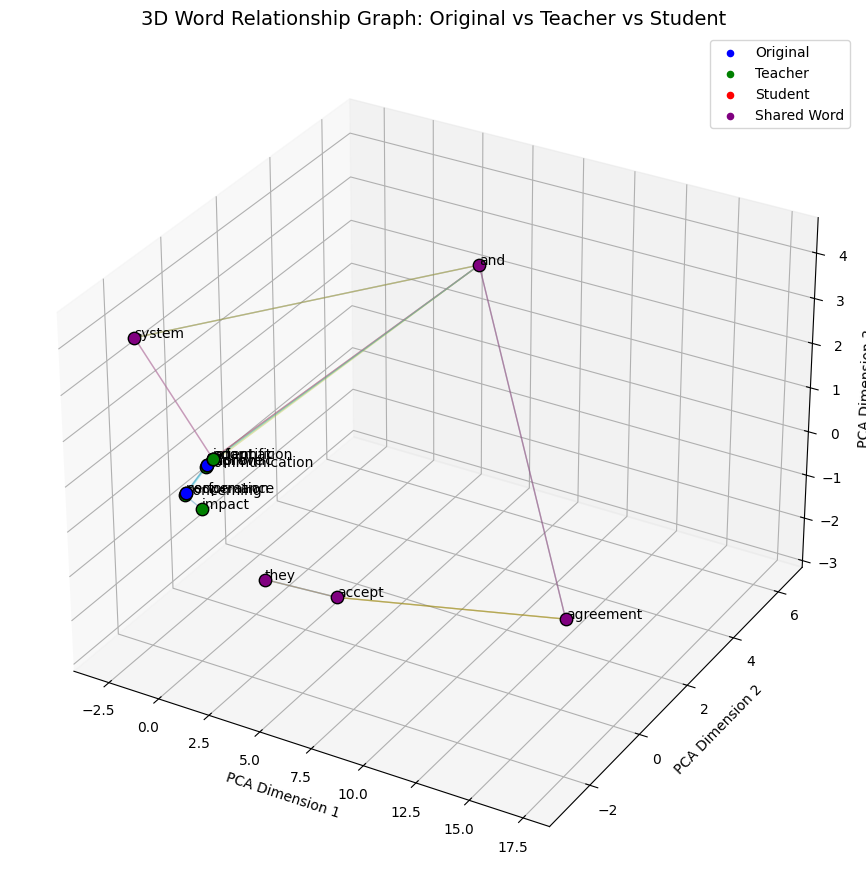


Word Presence Table
------------------------------------------------------------
Word            Original   Teacher    Student   
------------------------------------------------------------
accept          YES        YES        YES       
adapt           YES        NO         NO        
agreement       YES        YES        YES       
and             YES        YES        YES       
communication   NO         YES        NO        
concerning      NO         YES        NO        
cooperation     NO         NO         YES       
economic        NO         NO         YES       
impact          NO         YES        NO        
improve         YES        NO         NO        
information     NO         NO         YES       
performance     YES        NO         NO        
scientific      NO         YES        NO        
system          YES        YES        YES       
they            YES        YES        YES       

Relationship Distortion
------------------------------------------------

In [142]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import defaultdict
from mpl_toolkits.mplot3d import Axes3D


texts = {
    "Original": original,
    "Teacher": teacher,
    "Student": student
}

colors = {
    "Original": "blue",
    "Teacher": "green",
    "Student": "red"
}

# ============================================================
# Text Processing
# ============================================================

def clean_text(text):
    return (
        text.lower()
        .replace("<start>", "")
        .replace(".", "")
        .replace(",", "")
        .strip()
    )

def tokenize(text):
    return clean_text(text).split()

tokenized_texts = {
    name: tokenize(text)
    for name, text in texts.items()
}

# ============================================================
# Vocabulary
# ============================================================

vocab = sorted(set(word for words in tokenized_texts.values() for word in words))
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}

# ============================================================
# Co-occurrence Matrix
# ============================================================

def build_cooccurrence_matrix(words, window_size=2):
    matrix = np.zeros((len(vocab), len(vocab)))

    for i, word in enumerate(words):
        center_id = word_to_id[word]

        left = max(0, i - window_size)
        right = min(len(words), i + window_size + 1)

        for j in range(left, right):
            if i == j:
                continue

            context_word = words[j]
            context_id = word_to_id[context_word]
            matrix[center_id][context_id] += 1

    return matrix

matrices = {
    name: build_cooccurrence_matrix(words, window_size=2)
    for name, words in tokenized_texts.items()
}

combined_matrix = sum(matrices.values())

# ============================================================
# 3D PCA
# ============================================================

pca = PCA(n_components=3)
coords = pca.fit_transform(combined_matrix)

word_coords = {
    word: coords[word_to_id[word]]
    for word in vocab
}

# ============================================================
# Word Source Detection
# ============================================================

word_sources = defaultdict(list)

for name, words in tokenized_texts.items():
    for word in set(words):
        word_sources[word].append(name)

def get_word_color(word):
    sources = word_sources[word]

    if len(sources) > 1:
        return "purple"

    return colors[sources[0]]

# ============================================================
# Build Edges
# ============================================================

edges = []

for name, words in tokenized_texts.items():
    for i in range(len(words) - 1):
        w1 = words[i]
        w2 = words[i + 1]
        edges.append((w1, w2, name))

# ============================================================
# Plot 3D Graph
# ============================================================

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Plot edges
for w1, w2, source in edges:
    x1, y1, z1 = word_coords[w1]
    x2, y2, z2 = word_coords[w2]

    ax.plot(
        [x1, x2],
        [y1, y2],
        [z1, z2],
        alpha=0.35,
        linewidth=1
    )

# Plot words
for word in vocab:
    x, y, z = word_coords[word]

    ax.scatter(
        x,
        y,
        z,
        s=80,
        color=get_word_color(word),
        edgecolor="black"
    )

    ax.text(
        x,
        y,
        z,
        word,
        fontsize=10
    )

ax.set_title("3D Word Relationship Graph: Original vs Teacher vs Student", fontsize=14)
ax.set_xlabel("PCA Dimension 1")
ax.set_ylabel("PCA Dimension 2")
ax.set_zlabel("PCA Dimension 3")

# Legend
for name, color in colors.items():
    ax.scatter([], [], [], color=color, label=name)

ax.scatter([], [], [], color="purple", label="Shared Word")

ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Word Presence Table
# ============================================================

print("\nWord Presence Table")
print("-" * 60)
print(f"{'Word':<15} {'Original':<10} {'Teacher':<10} {'Student':<10}")
print("-" * 60)

for word in vocab:
    row = [
        word,
        "YES" if word in tokenized_texts["Original"] else "NO",
        "YES" if word in tokenized_texts["Teacher"] else "NO",
        "YES" if word in tokenized_texts["Student"] else "NO",
    ]

    print(f"{row[0]:<15} {row[1]:<10} {row[2]:<10} {row[3]:<10}")

# ============================================================
# Relationship Distortion
# ============================================================

def relation_loss(matrix_a, matrix_b):
    return np.mean((matrix_a - matrix_b) ** 2)

print("\nRelationship Distortion")
print("-" * 60)
print("Original vs Teacher :", relation_loss(matrices["Original"], matrices["Teacher"]))
print("Original vs Student :", relation_loss(matrices["Original"], matrices["Student"]))
print("Teacher vs Student  :", relation_loss(matrices["Teacher"], matrices["Student"]))

In [4]:
torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


device(type='cuda', index=0)